
#  PROYEK UJIAN AKHIR SEMESTER
## Kelompok C Kelas Data Mining I SD-A1


* Dara Devinta Faradhilla (164221002)
* Brilliant Prigar Ednesto (164221024)
* Reinhart Ananda Siswadi (164221046)
* Romero Rachmat Musadat (164221070)
* Muhammad Firdaus Mu'afi (164221092)


# 1. Call Dataset

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn import tree
from sklearn.linear_model import LogisticRegression

In [ ]:
#df = pd.read_csv("Untitled form (Responses).csv", sep=";")
df = pd.read_excel("/content/Response Survei Kelompok C.xlsx")
df.head()

,Timestamp,Nama,Jenis_Kelamin,usia,pendapatan,transportasi,makan,masak_sendiri,belanja_online,nongkrong,tabung,merasa_cukup,merokok,aktif_org,jajan_mall,ojol,pengeluaran
0,2024-05-27 11:38:57.362,oo,Perempuan,20,1.500.001 - 2.000.000 IDR,Motor,Dua kali,Selalu membeli makanan di luar,1-2 kali,1-2 kali,"Ya, kadang-kadang","Cukup, tetapi tidak selalu bisa menabung",Tidak,Tidak,Sering,Jarang,1.500.001 - 2.000.000 IDR
1,2024-05-27 11:39:32.731,A,Perempuan,19,< 1.000.000 IDR,Taksi/Gojek/Grab,Tiga kali,Selalu memasak sendiri,1-2 kali,3-5 kali,"Ya, selalu",Selalu cukup,Tidak,Ya,Lumayan,Tidak Pernah,500.000 - 1.000.000 IDR
2,2024-05-27 11:40:05.356,Rexy,Laki-laki,20,> 2.500.000,Mobil,Dua kali,Selalu membeli makanan di luar,1-2 kali,Lebih dari 5 kali,"Ya, selalu",Selalu cukup,Tidak,Ya,Jarang,Jarang,1.000.001 - 1.500.000 IDR
3,2024-05-27 11:42:19.035,Adam,Laki-laki,20,< 1.000.000 IDR,Motor,Dua kali,Selalu membeli makanan di luar,Tidak Pernah,1-2 kali,"Ya, kadang-kadang","Cukup, tetapi tidak selalu bisa menabung",Tidak,Tidak,Jarang,Tidak Pernah,500.000 - 1.000.000 IDR
4,2024-05-27 11:47:54.213,Elzandi,Laki-laki,20,> 2.500.000,Motor,Dua kali,Lebih sering membeli makanan di luar,3-5 kali,Lebih dari 5 kali,"Ya, kadang-kadang","Cukup, tetapi tidak selalu bisa menabung",Tidak,Tidak,Jarang,Jarang,> 2.000.000 IDR


# 2. Pre-processing

In [ ]:
df = df.drop(['Timestamp', 'Nama'], axis=1)

In [ ]:
dfminususia = df.drop(columns=['usia'])

dfminususia.describe(include='all')


,Jenis_Kelamin,pendapatan,transportasi,makan,masak_sendiri,belanja_online,nongkrong,tabung,merasa_cukup,merokok,aktif_org,jajan_mall,ojol,pengeluaran
count,94,94,94,94,94,94,94,94,94,94,94,94,94,94
unique,2,5,6,3,4,4,4,3,3,2,2,3,3,5
top,Perempuan,1.000.000 - 1.500.000 IDR,Motor,Dua kali,Lebih sering membeli makanan di luar,1-2 kali,1-2 kali,"Ya, kadang-kadang","Cukup, tetapi tidak selalu bisa menabung",Tidak,Ya,Jarang,Jarang,1.000.001 - 1.500.000 IDR
freq,49,25,55,51,46,55,41,50,51,85,53,58,53,27


In [ ]:
print(df.shape)

(94, 15)


In [ ]:
sumstat = df.describe()
print("Summary Stat:")
sumstat.head()

Summary Stat:


,usia
count,94.000000
mean,19.712766
std,0.632835
min,19.000000
25%,19.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Jenis_Kelamin   94 non-null     object
 1   usia            94 non-null     int64 
 2   pendapatan      94 non-null     object
 3   transportasi    94 non-null     object
 4   makan           94 non-null     object
 5   masak_sendiri   94 non-null     object
 6   belanja_online  94 non-null     object
 7   nongkrong       94 non-null     object
 8   tabung          94 non-null     object
 9   merasa_cukup    94 non-null     object
 10  merokok         94 non-null     object
 11  aktif_org       94 non-null     object
 12  jajan_mall      94 non-null     object
 13  ojol            94 non-null     object
 14  pengeluaran     94 non-null     object
dtypes: int64(1), object(14)
memory usage: 11.1+ KB


In [ ]:
df.describe()

,usia
count,94.000000
mean,19.712766
std,0.632835
min,19.000000
25%,19.000000
50%,20.000000
75%,20.000000
max,22.000000


## Transform Variabel

### Transform Variabel: pendaptan

In [ ]:
# Define the mapping function
def map_pendapatan(pendapatan):
    if pendapatan == '< 1.000.000 IDR':
        return '< 2.000.000 IDR'
    elif pendapatan == '1.000.000 - 1.500.000 IDR':
        return '< 2.000.000 IDR'
    elif pendapatan == '1.500.001 - 2.000.000 IDR':
        return '=< 2.000.000 IDR'
    else:
        return '> 2.000.000 IDR'


# Apply the mapping function to transform the 'pendapatan' column
df['pendapatan'] = df['pendapatan'].apply(map_pendapatan)

# Display the transformed DataFrame
print("Transformed DataFrame:")
df.head()




Transformed DataFrame:


,Jenis_Kelamin,usia,pendapatan,transportasi,makan,masak_sendiri,belanja_online,nongkrong,tabung,merasa_cukup,merokok,aktif_org,jajan_mall,ojol,pengeluaran
0,Perempuan,20,=< 2.000.000 IDR,Motor,Dua kali,Selalu membeli makanan di luar,1-2 kali,1-2 kali,"Ya, kadang-kadang","Cukup, tetapi tidak selalu bisa menabung",Tidak,Tidak,Sering,Jarang,1.500.001 - 2.000.000 IDR
1,Perempuan,19,< 2.000.000 IDR,Taksi/Gojek/Grab,Tiga kali,Selalu memasak sendiri,1-2 kali,3-5 kali,"Ya, selalu",Selalu cukup,Tidak,Ya,Lumayan,Tidak Pernah,500.000 - 1.000.000 IDR
2,Laki-laki,20,> 2.000.000 IDR,Mobil,Dua kali,Selalu membeli makanan di luar,1-2 kali,Lebih dari 5 kali,"Ya, selalu",Selalu cukup,Tidak,Ya,Jarang,Jarang,1.000.001 - 1.500.000 IDR
3,Laki-laki,20,< 2.000.000 IDR,Motor,Dua kali,Selalu membeli makanan di luar,Tidak Pernah,1-2 kali,"Ya, kadang-kadang","Cukup, tetapi tidak selalu bisa menabung",Tidak,Tidak,Jarang,Tidak Pernah,500.000 - 1.000.000 IDR
4,Laki-laki,20,> 2.000.000 IDR,Motor,Dua kali,Lebih sering membeli makanan di luar,3-5 kali,Lebih dari 5 kali,"Ya, kadang-kadang","Cukup, tetapi tidak selalu bisa menabung",Tidak,Tidak,Jarang,Jarang,> 2.000.000 IDR


In [ ]:
df['pendapatan']

0     =< 2.000.000 IDR
1      < 2.000.000 IDR
2      > 2.000.000 IDR
3      < 2.000.000 IDR
4      > 2.000.000 IDR
            ...       
89     > 2.000.000 IDR
90     < 2.000.000 IDR
91     > 2.000.000 IDR
92    =< 2.000.000 IDR
93     < 2.000.000 IDR
Name: pendapatan, Length: 94, dtype: object

### a) Transform Variabel: Pengeluaran

In [ ]:

def map_pengeluaran(pengeluaran):
    if pengeluaran == '< 500.000 IDR':
        return '<= 1.000.000 IDR'
    elif pengeluaran == '500.000 - 1.000.000 IDR':
        return '<= 1.000.000 IDR'
    elif pengeluaran == '1.000.001 - 1.500.000 IDR':
        return '1.000.000 IDR - 2.000.000 IDR'
    elif pengeluaran == '1.500.001 - 2.000.000 IDR':
        return '1.000.000 IDR - 2.000.000 IDR'
    else:
        return '> 2.000.000 IDR'



# Apply the mapping function to transform the 'pendapatan' column
df['pengeluaran'] = df['pengeluaran'].apply(map_pengeluaran)

# Display the transformed DataFrame
print("Transformed DataFrame:")
df.head()




Transformed DataFrame:


,Jenis_Kelamin,usia,pendapatan,transportasi,makan,masak_sendiri,belanja_online,nongkrong,tabung,merasa_cukup,merokok,aktif_org,jajan_mall,ojol,pengeluaran
0,Perempuan,20,=< 2.000.000 IDR,Motor,Dua kali,Selalu membeli makanan di luar,1-2 kali,1-2 kali,"Ya, kadang-kadang","Cukup, tetapi tidak selalu bisa menabung",Tidak,Tidak,Sering,Jarang,1.000.000 IDR - 2.000.000 IDR
1,Perempuan,19,< 2.000.000 IDR,Taksi/Gojek/Grab,Tiga kali,Selalu memasak sendiri,1-2 kali,3-5 kali,"Ya, selalu",Selalu cukup,Tidak,Ya,Lumayan,Tidak Pernah,<= 1.000.000 IDR
2,Laki-laki,20,> 2.000.000 IDR,Mobil,Dua kali,Selalu membeli makanan di luar,1-2 kali,Lebih dari 5 kali,"Ya, selalu",Selalu cukup,Tidak,Ya,Jarang,Jarang,1.000.000 IDR - 2.000.000 IDR
3,Laki-laki,20,< 2.000.000 IDR,Motor,Dua kali,Selalu membeli makanan di luar,Tidak Pernah,1-2 kali,"Ya, kadang-kadang","Cukup, tetapi tidak selalu bisa menabung",Tidak,Tidak,Jarang,Tidak Pernah,<= 1.000.000 IDR
4,Laki-laki,20,> 2.000.000 IDR,Motor,Dua kali,Lebih sering membeli makanan di luar,3-5 kali,Lebih dari 5 kali,"Ya, kadang-kadang","Cukup, tetapi tidak selalu bisa menabung",Tidak,Tidak,Jarang,Jarang,> 2.000.000 IDR


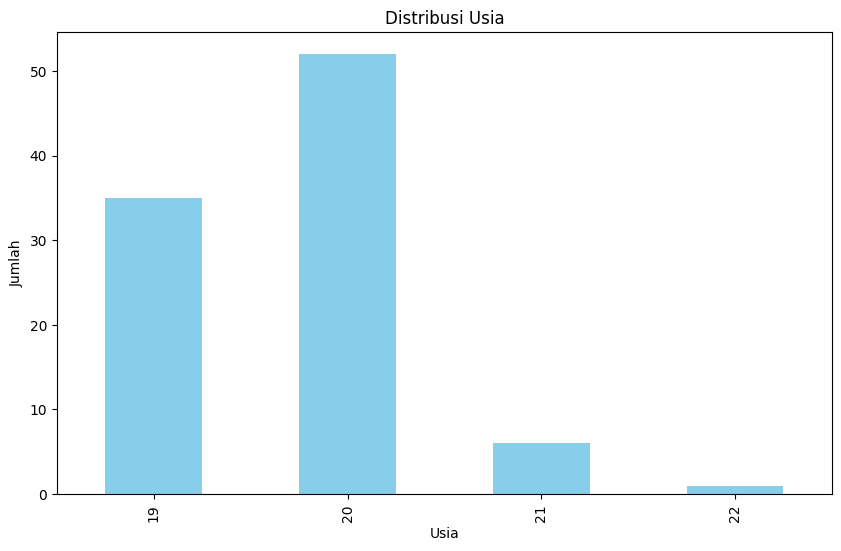

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Menghitung frekuensi masing-masing usia
usia_counts = df['usia'].value_counts().sort_index()

# Membuat barchart
plt.figure(figsize=(10, 6))
usia_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Usia')
plt.ylabel('Jumlah')
plt.title('Distribusi Usia')
plt.show()


In [ ]:
df.columns

Index(['Jenis_Kelamin', 'usia', 'pendapatan', 'transportasi', 'makan',
       'masak_sendiri', 'belanja_online', 'nongkrong', 'tabung',
       'merasa_cukup', 'merokok', 'aktif_org', 'jajan_mall', 'ojol',
       'pengeluaran'],
      dtype='object')

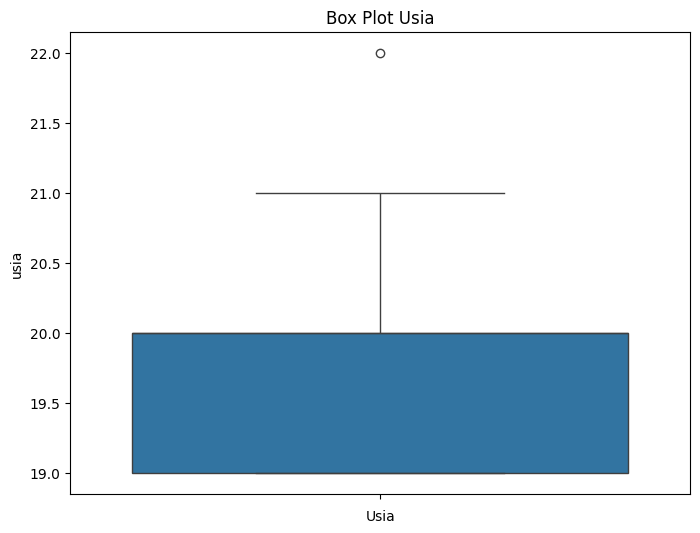

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat box plot untuk variabel usia
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='usia')
plt.title('Box Plot Usia')
plt.xlabel('Usia')
plt.show()


In [ ]:
df['pengeluaran']

0     1.000.000 IDR - 2.000.000 IDR
1                  <= 1.000.000 IDR
2     1.000.000 IDR - 2.000.000 IDR
3                  <= 1.000.000 IDR
4                   > 2.000.000 IDR
                  ...              
89    1.000.000 IDR - 2.000.000 IDR
90                 <= 1.000.000 IDR
91                  > 2.000.000 IDR
92                 <= 1.000.000 IDR
93                 <= 1.000.000 IDR
Name: pengeluaran, Length: 94, dtype: object

In [ ]:
print(df.columns)


Index(['Jenis_Kelamin', 'usia', 'pendapatan', 'transportasi', 'makan',
       'masak_sendiri', 'belanja_online', 'nongkrong', 'tabung',
       'merasa_cukup', 'merokok', 'aktif_org', 'jajan_mall', 'ojol',
       'pengeluaran'],
      dtype='object')


## b) Mencari Missing Value

In [ ]:
nadf = df.isna()
nadf.head()

,Jenis_Kelamin,usia,pendapatan,transportasi,makan,masak_sendiri,belanja_online,nongkrong,tabung,merasa_cukup,merokok,aktif_org,jajan_mall,ojol,pengeluaran
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
naval = df.isnull().sum().sum()
print(naval)

0


In [ ]:
df.columns

Index(['Jenis_Kelamin', 'usia', 'pendapatan', 'transportasi', 'makan',
       'masak_sendiri', 'belanja_online', 'nongkrong', 'tabung',
       'merasa_cukup', 'merokok', 'aktif_org', 'jajan_mall', 'ojol',
       'pengeluaran'],
      dtype='object')

<ipython-input-23-89084e0b5066>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis')
<ipython-input-23-89084e0b5066>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis')
<ipython-input-23-89084e0b5066>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette='viridis')
<ipython-input-23-89084e0b5066>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=

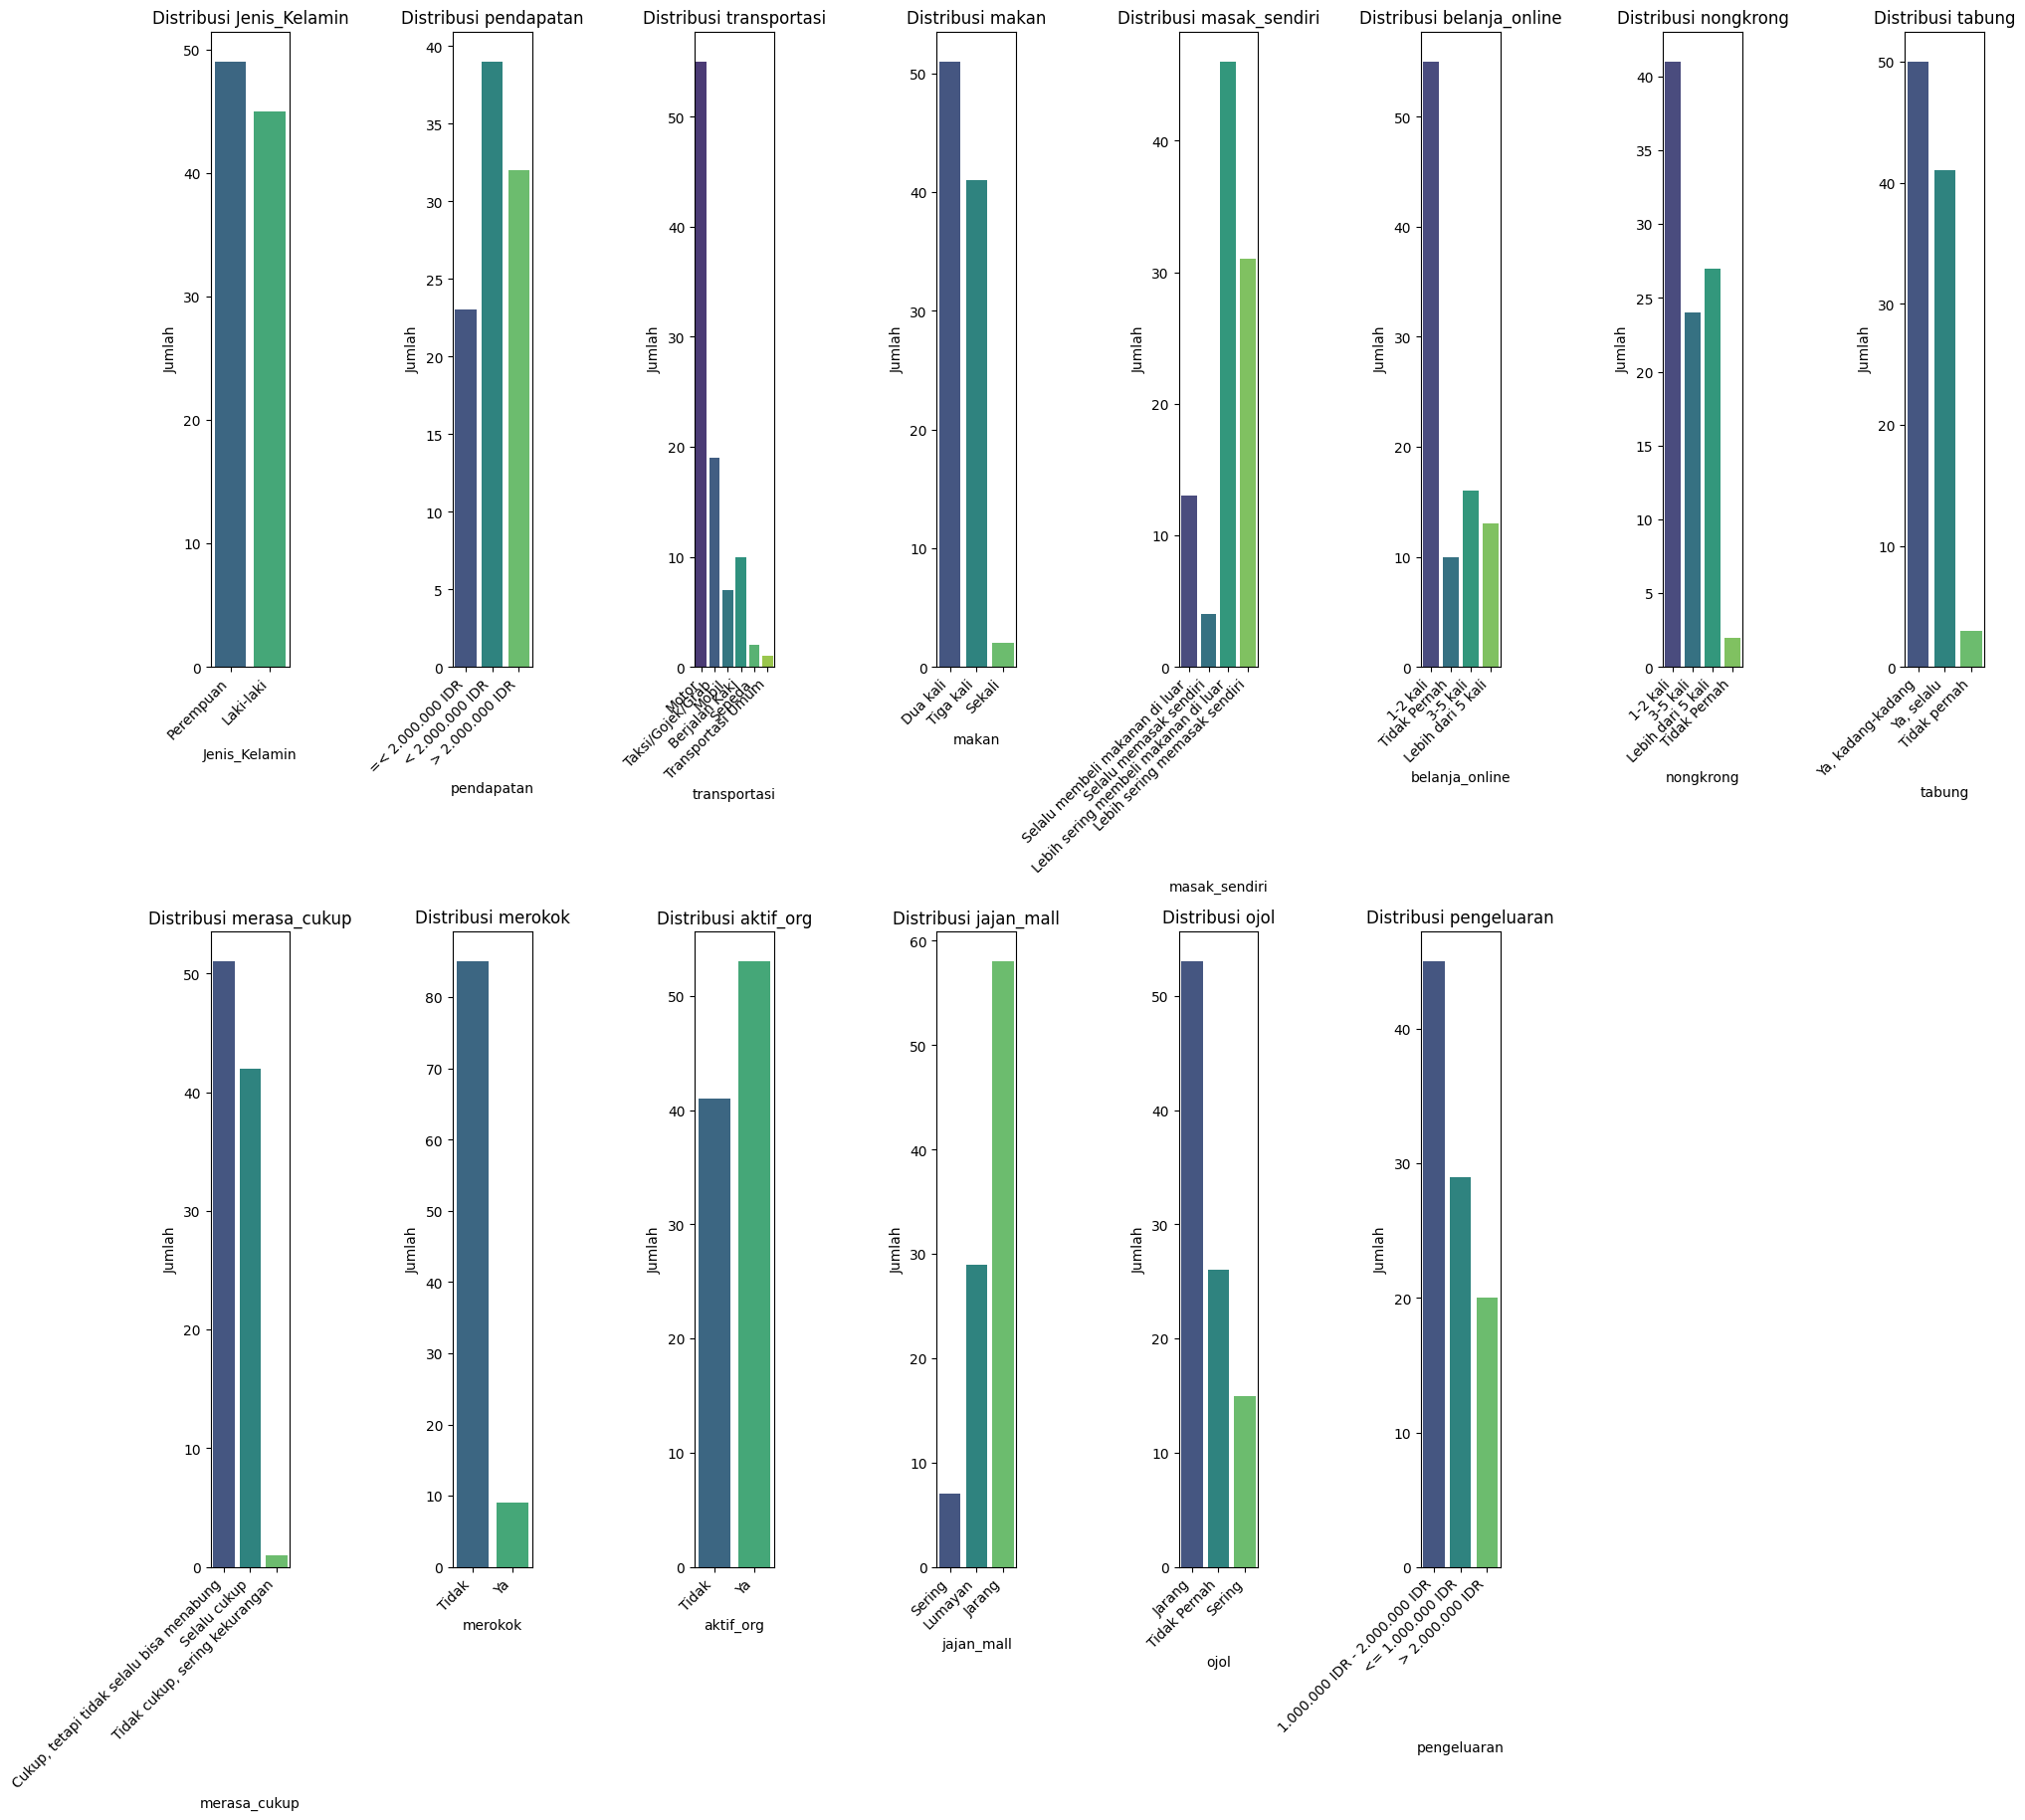

In [ ]:
variables = [
    'Jenis_Kelamin', 'pendapatan', 'transportasi', 'makan', 'masak_sendiri',
    'belanja_online', 'nongkrong', 'tabung', 'merasa_cukup', 'merokok',
    'aktif_org', 'jajan_mall', 'ojol', 'pengeluaran'
]

# Membuat histogram untuk setiap variabel
plt.figure(figsize=(20, 25))
for i, var in enumerate(variables, 1):
    plt.subplot(3, 8, i)
    sns.countplot(data=df, x=var, palette='viridis')
    plt.title(f'Distribusi {var}')
    plt.xlabel(var)
    plt.ylabel('Jumlah')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## c) Encoding

### (i) Encoding: Label Encoding

In [ ]:
label_encoders = {}
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

df.head()

,Jenis_Kelamin,usia,pendapatan,transportasi,makan,masak_sendiri,belanja_online,nongkrong,tabung,merasa_cukup,merokok,aktif_org,jajan_mall,ojol,pengeluaran
0,1,1,1,2,0,3,0,0,1,0,0,0,2,0,0
1,1,0,0,4,2,2,0,1,2,1,0,1,1,2,1
2,0,1,2,1,0,3,0,2,2,1,0,1,0,0,0
3,0,1,0,2,0,3,3,0,1,0,0,0,0,2,1
4,0,1,2,2,0,1,1,2,1,0,0,0,0,0,2


In [ ]:
df_encode = df.copy()

label_encoders = {}
for column in df_encode.columns:
    le = LabelEncoder()
    df_encode[column] = le.fit_transform(df_encode[column])
    label_encoders[column] = le

df_encode.head()

,Jenis_Kelamin,usia,pendapatan,transportasi,makan,masak_sendiri,belanja_online,nongkrong,tabung,merasa_cukup,merokok,aktif_org,jajan_mall,ojol,pengeluaran
0,1,1,1,2,0,3,0,0,1,0,0,0,2,0,0
1,1,0,0,4,2,2,0,1,2,1,0,1,1,2,1
2,0,1,2,1,0,3,0,2,2,1,0,1,0,0,0
3,0,1,0,2,0,3,3,0,1,0,0,0,0,2,1
4,0,1,2,2,0,1,1,2,1,0,0,0,0,0,2


### (ii) Encoding: Transformasi

In [ ]:
df_transformasi = df.copy()

label_encoders = {}
for column in df_transformasi.columns:
    le = LabelEncoder()
    df_transformasi[column] = le.fit_transform(df_transformasi[column])
    label_encoders[column] = le

scaler = StandardScaler()
numerical_columns = df_transformasi.columns
df_transformasi[numerical_columns] = scaler.fit_transform(df_transformasi[numerical_columns])

df_transformasi.head()

,Jenis_Kelamin,usia,pendapatan,transportasi,makan,masak_sendiri,belanja_online,nongkrong,tabung,merasa_cukup,merokok,aktif_org,jajan_mall,ojol,pengeluaran
0,0.958315,0.456318,0.086001,-0.144033,-0.908546,2.090089,-0.732258,-1.000851,-0.732396,-0.900400,-0.325396,-1.136962,2.447802,-0.818719,-0.931667
1,0.958315,-1.132345,-1.068874,1.548356,1.124867,1.050574,-0.732258,0.119149,1.079321,1.023182,-0.325396,0.879537,0.860951,1.478581,0.337561
2,-1.043498,0.456318,1.240876,-0.990228,-0.908546,2.090089,-0.732258,1.239149,1.079321,1.023182,-0.325396,0.879537,-0.725900,-0.818719,-0.931667
3,-1.043498,0.456318,-1.068874,-0.144033,-0.908546,2.090089,2.135753,-1.000851,-0.732396,-0.900400,-0.325396,-1.136962,-0.725900,1.478581,0.337561
4,-1.043498,0.456318,1.240876,-0.144033,-0.908546,0.011059,0.223746,1.239149,-0.732396,-0.900400,-0.325396,-1.136962,-0.725900,-0.818719,1.606788


<ipython-input-27-6666902c7c2e>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='pendapatan', palette='viridis', order=pendapatan_counts.index)


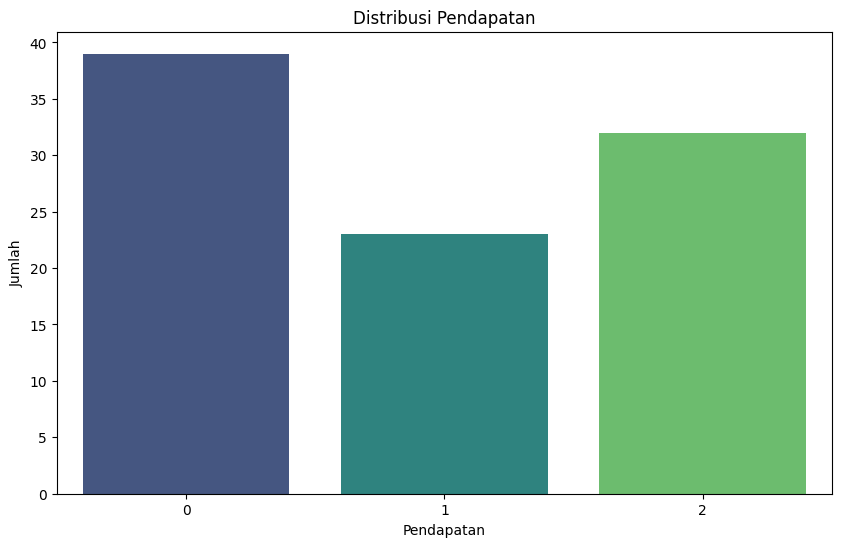

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pendapatan_counts = df['pendapatan'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='pendapatan', palette='viridis', order=pendapatan_counts.index)
plt.xlabel('Pendapatan')
plt.ylabel('Jumlah')
plt.title('Distribusi Pendapatan')
plt.show()


In [ ]:
df.columns

Index(['Jenis_Kelamin', 'usia', 'pendapatan', 'transportasi', 'makan',
       'masak_sendiri', 'belanja_online', 'nongkrong', 'tabung',
       'merasa_cukup', 'merokok', 'aktif_org', 'jajan_mall', 'ojol',
       'pengeluaran'],
      dtype='object')

### (iii) Encoding: One-hot Encoding

In [ ]:
df_oneencoded = pd.get_dummies(df)

df_oneencoded = df_oneencoded.applymap(lambda x: 1 if x > 0 else 0)

df_oneencoded.head(15)

,Jenis_Kelamin,usia,pendapatan,transportasi,makan,masak_sendiri,belanja_online,nongkrong,tabung,merasa_cukup,merokok,aktif_org,jajan_mall,ojol,pengeluaran
0,1,1,1,1,0,1,0,0,1,0,0,0,1,0,0
1,1,0,0,1,1,1,0,1,1,1,0,1,1,1,1
2,0,1,1,1,0,1,0,1,1,1,0,1,0,0,0
3,0,1,0,1,0,1,1,0,1,0,0,0,0,1,1
4,0,1,1,1,0,1,1,1,1,0,0,0,0,0,1
5,1,1,0,1,0,0,0,0,1,1,0,0,0,1,1
6,1,1,1,1,0,1,1,1,1,0,0,0,0,0,0
7,0,0,1,1,1,0,0,0,1,1,0,1,1,0,1
8,1,1,1,0,0,1,0,0,1,1,0,1,0,0,0
9,1,1,0,1,1,0,0,1,1,0,0,1,1,1,1


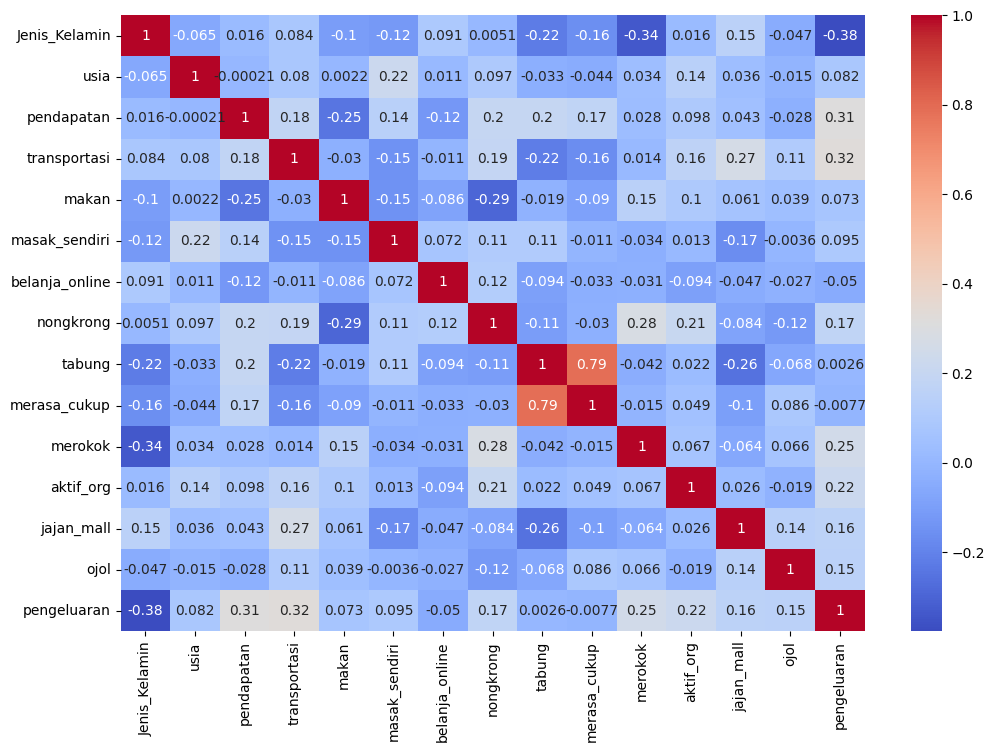

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung korelasi antara fitur-fitur
correlation_matrix = df.corr()

# Plot heatmap dari korelasi
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()


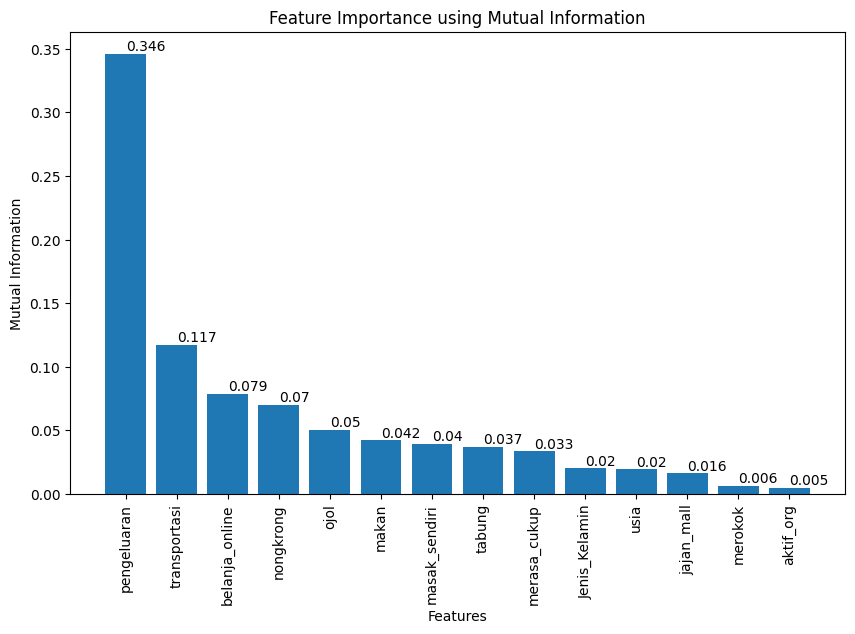

pengeluaran       0.346106
transportasi      0.117269
belanja_online    0.078583
nongkrong         0.070213
ojol              0.050240
makan             0.042120
masak_sendiri     0.039587
tabung            0.037090
merasa_cukup      0.033412
Jenis_Kelamin     0.020231
usia              0.019505
jajan_mall        0.016183
merokok           0.006412
aktif_org         0.004805
dtype: float64


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

# Assuming df_encode is already defined and encoded
y = df['pendapatan']
X = df.drop('pendapatan', axis=1)

# Calculate mutual information
mi = mutual_info_classif(X, y, discrete_features=True)

# Convert to a pandas series for easy plotting
mi_series = pd.Series(mi, index=X.columns)
mi_series = mi_series.sort_values(ascending=False)

# Plot mutual information values with annotations
plt.figure(figsize=(10, 6))
bars = plt.bar(mi_series.index, mi_series.values)

plt.title('Feature Importance using Mutual Information')
plt.xlabel('Features')
plt.ylabel('Mutual Information')

# Annotate bars with mutual information values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3), va='bottom')

# Rotate x-axis labels vertically
plt.xticks(rotation=90)

plt.show()

# Print mutual information values
print(mi_series)


## d) Drop kolom yg tdk digunakan

In [ ]:
df = df.drop(['merokok', 'aktif_org', 'usia', 'jajan_mall'], axis=1)

In [ ]:
print("Data setelah dropping columns:")
df.head()

Data setelah dropping columns:


,Jenis_Kelamin,pendapatan,transportasi,makan,masak_sendiri,belanja_online,nongkrong,tabung,merasa_cukup,ojol,pengeluaran
0,1,1,2,0,3,0,0,1,0,0,0
1,1,0,4,2,2,0,1,2,1,2,1
2,0,2,1,0,3,0,2,2,1,0,0
3,0,0,2,0,3,3,0,1,0,2,1
4,0,2,2,0,1,1,2,1,0,0,2


In [ ]:
print(df.columns)


Index(['Jenis_Kelamin', 'pendapatan', 'transportasi', 'makan', 'masak_sendiri',
       'belanja_online', 'nongkrong', 'tabung', 'merasa_cukup', 'ojol',
       'pengeluaran'],
      dtype='object')


In [ ]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler

# Count occurrences of each class in 'pendapatan' column before balancing
counts_before = df_encode['pendapatan'].value_counts()
print("Counts before balancing:\n", counts_before)

# Separate features (X) and target (y)
X = df_encode.drop(columns=['pendapatan'])
y = df_encode['pendapatan']

# Apply RandomOverSampler to balance the dataset
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Combine resampled features and target back into a DataFrame
df_resampled = pd.concat([X_resampled, y_resampled], axis=1)

# Count occurrences of each class in 'pendapatan' column after balancing
counts_after = df_resampled['pendapatan'].value_counts()
print("Counts after balancing:\n", counts_after)


Counts before balancing:
 pendapatan
0    39
2    32
1    23
Name: count, dtype: int64
Counts after balancing:
 pendapatan
1    39
0    39
2    39
Name: count, dtype: int64


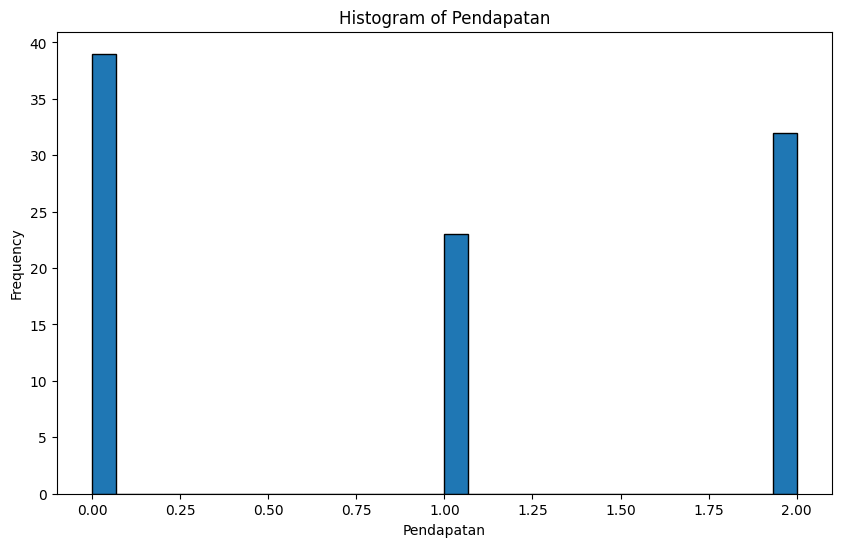

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_encode is already defined and loaded
pendapatan = df['pendapatan']

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(pendapatan, bins=30, edgecolor='k')
plt.title('Histogram of Pendapatan')
plt.xlabel('Pendapatan')
plt.ylabel('Frequency')
plt.show()


# 3. Train Model

In [ ]:
df_resampled.columns = df_resampled.columns.str.strip()

In [ ]:
pendapatan = 'pendapatan'

In [ ]:
y= df_resampled[pendapatan]
x= df_resampled.drop([pendapatan],axis=1)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 4. Machine Learning Model




## a) Decision Tree

In [ ]:
dtree = tree.DecisionTreeClassifier(random_state=42)
dtree.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
cv_scores = cross_val_score(dtree, x_train, y_train, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Mean Cross-Validation Score:", np.mean(cv_scores))

Cross-Validation Scores: [0.63157895 0.57894737 0.84210526 0.83333333 0.55555556]
Mean Cross-Validation Score: 0.6883040935672515


In [ ]:
dtreepred = dtree.predict(x_test)
precision = precision_score(y_test, dtreepred, average='weighted')
recall = recall_score(y_test, dtreepred, average='weighted')
f1 = f1_score(y_test, dtreepred, average='weighted')

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, dtreepred)
print("Confusion Matrix\n", cm)

Confusion Matrix
 [[3 2 1]
 [4 5 0]
 [0 0 9]]


In [ ]:
print("\nHasil Precision, Recall, F1-score dari Decision Tree (DT):")
print("============================================================")
print("- Precision :", precision)
print("- Recall    :", recall)
print("- F1-score  :", f1)
print("============================================================\n")

print("\nClassification Report:")
print("============================================================")
print(classification_report(y_test, dtreepred))
print("============================================================")
print("Accuracy of Decision Tree is:", accuracy_score(y_test, dtreepred) * 100)
print("============================================================")




Hasil Precision, Recall, F1-score dari Decision Tree (DT):
- Precision : 0.7125
- Recall    : 0.7083333333333334
- F1-score  : 0.7050227732793523


Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.50      0.46         6
           1       0.71      0.56      0.63         9
           2       0.90      1.00      0.95         9

    accuracy                           0.71        24
   macro avg       0.68      0.69      0.68        24
weighted avg       0.71      0.71      0.71        24

Accuracy of Decision Tree is: 70.83333333333334


In [ ]:
dt_accuracy = accuracy_score(y_test, dtreepred) * 100

In [ ]:
# Feature Importance
feature_importance = dtree.feature_importances_
print("Feature Importance:")
for i, feature in enumerate(x_train.columns):
    print(f"{feature}: {feature_importance[i]}")

Feature Importance:
Jenis_Kelamin: 0.02356639309764309
usia: 0.032498664529914505
transportasi: 0.06426790801790802
makan: 0.07842261904761905
masak_sendiri: 0.016439393939393927
belanja_online: 0.06648771367521362
nongkrong: 0.06458333333333333
tabung: 0.0749627976190476
merasa_cukup: 0.11292005394476323
merokok: 0.027678571428571448
aktif_org: 0.05274305555555561
jajan_mall: 0.03790737593943416
ojol: 0.0699949833152958
pengeluaran: 0.2775271365563065


## b) Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
cv_scores_rf = cross_val_score(rf, x_train, y_train, cv=5)
print("Cross-Validation Scores for Random Forest:", cv_scores_rf)
print("Mean Cross-Validation Score for Random Forest:", np.mean(cv_scores_rf))

rf_pred = rf.predict(x_test)

Cross-Validation Scores for Random Forest: [0.68421053 0.57894737 0.89473684 0.83333333 0.61111111]
Mean Cross-Validation Score for Random Forest: 0.72046783625731


In [ ]:
precision_rf = precision_score(y_test, rf_pred, average='weighted')
recall_rf = recall_score(y_test, rf_pred, average='weighted')
f1_rf = f1_score(y_test, rf_pred, average='weighted')

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, rf_pred)
print("Confusion Matrix\n", cm)

Confusion Matrix
 [[4 1 1]
 [2 7 0]
 [0 0 9]]


In [ ]:
print("\nHasil Precision, Recall, F1-score dari Random Forest (RF):")
print("============================================================")
print("- Precision :", precision_rf)
print("- Recall    :", recall_rf)
print("- F1-score  :", f1_rf)
print("============================================================\n")

print("\nClassification Report untuk Random Forest:")
print("============================================================")
print(classification_report(y_test, rf_pred))
print("============================================================")
print("Accuracy of Random Forest is:", accuracy_score(y_test, rf_pred) * 100)
print("============================================================")



Hasil Precision, Recall, F1-score dari Random Forest (RF):
- Precision : 0.8322916666666668
- Recall    : 0.8333333333333334
- F1-score  : 0.8307533539731683


Classification Report untuk Random Forest:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         6
           1       0.88      0.78      0.82         9
           2       0.90      1.00      0.95         9

    accuracy                           0.83        24
   macro avg       0.81      0.81      0.81        24
weighted avg       0.83      0.83      0.83        24

Accuracy of Random Forest is: 83.33333333333334


In [ ]:
rf_accuracy = accuracy_score(y_test, rf_pred) * 100

In [ ]:
# Feature Importance
feature_importance = rf.feature_importances_
print("Feature Importance:")
for i, feature in enumerate(x_train.columns):
    print(f"{feature}: {feature_importance[i]}")

Feature Importance:
Jenis_Kelamin: 0.04521518091742597
usia: 0.06904458613815305
transportasi: 0.08778373577933202
makan: 0.06376516280079796
masak_sendiri: 0.0559667914995864
belanja_online: 0.08509401787862128
nongkrong: 0.0876512139271992
tabung: 0.05595555601956896
merasa_cukup: 0.0485584586306635
merokok: 0.02619600285976129
aktif_org: 0.05959330282453784
jajan_mall: 0.07205746005024438
ojol: 0.07737168101788439
pengeluaran: 0.1657468496562237


## c) KNN Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, accuracy_score
import numpy as np

# Inisialisasi model K-Nearest Neighbors
knn_model = KNeighborsClassifier()

# Melatih model pada data latih
knn_model.fit(x_train, y_train)

# Evaluasi model menggunakan cross-validation
cv_scores_knn = cross_val_score(knn_model, x_train, y_train, cv=5)
print("Cross-Validation Scores for K-Nearest Neighbors:", cv_scores_knn)
print("Mean Cross-Validation Score for K-Nearest Neighbors:", np.mean(cv_scores_knn))

# Membuat prediksi menggunakan data uji
knn_pred = knn_model.predict(x_test)

# Menghitung metrik evaluasi
precision_knn = precision_score(y_test, knn_pred, average='weighted')
recall_knn = recall_score(y_test, knn_pred, average='weighted')
f1_knn = f1_score(y_test, knn_pred, average='weighted')

# Menampilkan hasil metrik evaluasi
print("\nHasil Precision, Recall, F1-score dari K-Nearest Neighbors:")
print("============================================================")
print("- Precision :", precision_knn)
print("- Recall    :", recall_knn)
print("- F1-score  :", f1_knn)
print("============================================================\n")

# Menampilkan classification report
print("\nClassification Report untuk K-Nearest Neighbors:")
print("============================================================")
print(classification_report(y_test, knn_pred))
print("============================================================")

# Menampilkan akurasi
accuracy_knn = accuracy_score(y_test, knn_pred) * 100
print("Accuracy of K-Nearest Neighbors is:", accuracy_knn)
print("============================================================")


Cross-Validation Scores for K-Nearest Neighbors: [0.36842105 0.36842105 0.63157895 0.5        0.44444444]
Mean Cross-Validation Score for K-Nearest Neighbors: 0.4625730994152047

Hasil Precision, Recall, F1-score dari K-Nearest Neighbors:
- Precision : 0.78125
- Recall    : 0.7083333333333334
- F1-score  : 0.7209558823529413


Classification Report untuk K-Nearest Neighbors:
              precision    recall  f1-score   support

           0       0.50      0.83      0.62         6
           1       0.75      0.67      0.71         9
           2       1.00      0.67      0.80         9

    accuracy                           0.71        24
   macro avg       0.75      0.72      0.71        24
weighted avg       0.78      0.71      0.72        24

Accuracy of K-Nearest Neighbors is: 70.83333333333334


## d) Bagging

### (i) Bagging: Decision Tree

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi model Decision Tree
base_classifier = DecisionTreeClassifier(random_state=42)

# Inisialisasi model Bagging dengan Decision Tree sebagai estimator base
bagging_model = BaggingClassifier(base_classifier, random_state=42)

# Melatih model pada data latih
bagging_model.fit(x_train, y_train)

# Evaluasi model menggunakan cross-validation
cv_scores_bagging = cross_val_score(bagging_model, x_train, y_train, cv=5)
print("Cross-Validation Scores for Bagging with Decision Tree:", cv_scores_bagging)
print("Mean Cross-Validation Score for Bagging with Decision Tree:", np.mean(cv_scores_bagging))

# Membuat prediksi menggunakan data uji
bagging_pred = bagging_model.predict(x_test)

# Menghitung metrik evaluasi
precision_bagging = precision_score(y_test, bagging_pred, average='weighted')
recall_bagging = recall_score(y_test, bagging_pred, average='weighted')
f1_bagging = f1_score(y_test, bagging_pred, average='weighted')

# Menampilkan hasil metrik evaluasi
print("\nHasil Precision, Recall, F1-score dari Bagging with Decision Tree:")
print("============================================================")
print("- Precision :", precision_bagging)
print("- Recall    :", recall_bagging)
print("- F1-score  :", f1_bagging)
print("============================================================\n")

# Menampilkan classification report
print("\nClassification Report untuk Bagging with Decision Tree:")
print("============================================================")
print(classification_report(y_test, bagging_pred))
print("============================================================")

# Menampilkan akurasi
accuracy_bagging_dt = accuracy_score(y_test, bagging_pred) * 100
print("Accuracy of Bagging with Decision Tree is:", accuracy_bagging_dt)
print("============================================================")

# Inisialisasi list untuk menyimpan *feature importance* dari setiap estimator
feature_importances = []

# Mengakses setiap estimator dalam bagging_model
for estimator in bagging_model.estimators_:
    # Mengakses *feature importance* dari estimator saat ini
    feature_importances.append(estimator.feature_importances_)

# Menghitung rata-rata *feature importance* dari semua estimator
average_feature_importance = np.mean(feature_importances, axis=0)

# Menampilkan *feature importance* untuk setiap fitur
print("Feature Importance:")
for i, feature in enumerate(x_train.columns):
    print(f"{feature}: {average_feature_importance[i]}")

Cross-Validation Scores for Bagging with Decision Tree: [0.73684211 0.57894737 0.94736842 0.83333333 0.55555556]
Mean Cross-Validation Score for Bagging with Decision Tree: 0.7304093567251462

Hasil Precision, Recall, F1-score dari Bagging with Decision Tree:
- Precision : 0.8322916666666668
- Recall    : 0.8333333333333334
- F1-score  : 0.8307533539731683


Classification Report untuk Bagging with Decision Tree:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         6
           1       0.88      0.78      0.82         9
           2       0.90      1.00      0.95         9

    accuracy                           0.83        24
   macro avg       0.81      0.81      0.81        24
weighted avg       0.83      0.83      0.83        24

Accuracy of Bagging with Decision Tree is: 83.33333333333334
Feature Importance:
Jenis_Kelamin: 0.018887108669291823
usia: 0.03696669289824221
transportasi: 0.06414858159099948
makan: 0.0462440691981011

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, bagging_pred)
print("Confusion Matrix\n", cm)

Confusion Matrix
 [[4 1 1]
 [2 7 0]
 [0 0 9]]


### (ii) Bagging: Random forest

In [ ]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, accuracy_score
import numpy as np

# Inisialisasi model Random Forest
base_classifier = RandomForestClassifier(random_state=42)

# Inisialisasi model Bagging dengan Random Forest sebagai estimator base
bagging_model = BaggingClassifier(base_classifier, random_state=42)

# Melatih model pada data latih
bagging_model.fit(x_train, y_train)

# Evaluasi model menggunakan cross-validation
cv_scores_bagging = cross_val_score(bagging_model, x_train, y_train, cv=5)
print("Cross-Validation Scores for Bagging with Random Forest:", cv_scores_bagging)
print("Mean Cross-Validation Score for Bagging with Random Forest:", np.mean(cv_scores_bagging))

# Membuat prediksi menggunakan data uji
bagging_pred_rf = bagging_model.predict(x_test)

# Menghitung metrik evaluasi
precision_bagging = precision_score(y_test, bagging_pred_rf, average='weighted')
recall_bagging = recall_score(y_test, bagging_pred_rf, average='weighted')
f1_bagging = f1_score(y_test, bagging_pred_rf, average='weighted')

# Menampilkan hasil metrik evaluasi
print("\nHasil Precision, Recall, F1-score dari Bagging with Random Forest:")
print("============================================================")
print("- Precision :", precision_bagging)
print("- Recall    :", recall_bagging)
print("- F1-score  :", f1_bagging)
print("============================================================\n")

# Menampilkan classification report
print("\nClassification Report untuk Bagging with Random Forest:")
print("============================================================")
print(classification_report(y_test, bagging_pred_rf))
print("============================================================")

# Menampilkan akurasi
accuracy_bagging_rf = accuracy_score(y_test, bagging_pred_rf) * 100
print("Accuracy of Bagging with Random Forest is:", accuracy_bagging_rf)
print("============================================================")

# Inisialisasi list untuk menyimpan *feature importance* dari setiap estimator
feature_importances = []

# Mengakses setiap estimator dalam bagging_model
for estimator in bagging_model.estimators_:
    # Mengakses *feature importance* dari estimator saat ini
    feature_importances.append(estimator.feature_importances_)

# Menghitung rata-rata *feature importance* dari semua estimator
average_feature_importance = np.mean(feature_importances, axis=0)

# Menampilkan *feature importance* untuk setiap fitur
print("Feature Importance:")
for i, feature in enumerate(x_train.columns):
    print(f"{feature}: {average_feature_importance[i]}")


Cross-Validation Scores for Bagging with Random Forest: [0.73684211 0.57894737 0.94736842 0.72222222 0.55555556]
Mean Cross-Validation Score for Bagging with Random Forest: 0.708187134502924

Hasil Precision, Recall, F1-score dari Bagging with Random Forest:
- Precision : 0.8708333333333332
- Recall    : 0.875
- F1-score  : 0.870414673046252


Classification Report untuk Bagging with Random Forest:
              precision    recall  f1-score   support

           0       0.80      0.67      0.73         6
           1       0.89      0.89      0.89         9
           2       0.90      1.00      0.95         9

    accuracy                           0.88        24
   macro avg       0.86      0.85      0.85        24
weighted avg       0.87      0.88      0.87        24

Accuracy of Bagging with Random Forest is: 87.5
Feature Importance:
Jenis_Kelamin: 0.041462428842448454
usia: 0.06441787139077834
transportasi: 0.08451490729886614
makan: 0.0725870909909165
masak_sendiri: 0.0770129259

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, bagging_pred_rf)
print("Confusion Matrix\n", cm)

Confusion Matrix
 [[4 1 1]
 [1 8 0]
 [0 0 9]]


## d) Naive-Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Instantiate Multinomial Naive Bayes classifier
nb_multinomial = MultinomialNB()

# Train the classifier
nb_multinomial.fit(x_train, y_train)

# Perform cross-validation
cv_scores = cross_val_score(nb_multinomial, x_train, y_train, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Mean Cross-Validation Score:", np.mean(cv_scores))

# Make predictions
nb_multinomial_pred = nb_multinomial.predict(x_test)

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, nb_multinomial_pred, average='weighted')
recall = recall_score(y_test, nb_multinomial_pred, average='weighted')
f1 = f1_score(y_test, nb_multinomial_pred, average='weighted')

# Print results
print("\nHasil Precision, Recall, F1-score dari Naive Bayes (Multinomial):")
print("============================================================")
print("- Precision :", precision)
print("- Recall    :", recall)
print("- F1-score  :", f1)
print("============================================================\n")

# Print classification report
print("\nClassification Report:")
print("============================================================")
print(classification_report(y_test, nb_multinomial_pred))
print("============================================================")

# Print accuracy
print("Accuracy of Naive Bayes (Multinomial) is:", accuracy_score(y_test, nb_multinomial_pred) * 100)
print("============================================================")

Cross-Validation Scores: [0.52631579 0.42105263 0.47368421 0.33333333 0.44444444]
Mean Cross-Validation Score: 0.439766081871345

Hasil Precision, Recall, F1-score dari Naive Bayes (Multinomial):
- Precision : 0.6582792207792209
- Recall    : 0.625
- F1-score  : 0.6278846153846155


Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.50      0.46         6
           1       0.64      0.78      0.70         9
           2       0.83      0.56      0.67         9

    accuracy                           0.62        24
   macro avg       0.63      0.61      0.61        24
weighted avg       0.66      0.62      0.63        24

Accuracy of Naive Bayes (Multinomial) is: 62.5


In [ ]:
nb_multinomial_accuracy = accuracy_score(y_test, nb_multinomial_pred) * 100

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, nb_multinomial_pred)
print("Confusion Matrix\n", cm)

Confusion Matrix
 [[3 2 1]
 [2 7 0]
 [2 2 5]]


## e) ANN: Backwards-Propagation

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Assuming x_train, y_train, x_test, y_test are already defined and preprocessed

# Convert labels to categorical one-hot encoding
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

# Define the model
model = Sequential()
model.add(Dense(64, input_dim=x_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(y_train_categorical.shape[1], activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train_categorical, epochs=50, batch_size=60, validation_split=0.2)

# Make predictions using the test data
y_pred_proba = model.predict(x_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# Calculate evaluation metrics
precision_ann = precision_score(y_test, y_pred, average='weighted')
recall_ann = recall_score(y_test, y_pred, average='weighted')
f1_ann = f1_score(y_test, y_pred, average='weighted')

# Display evaluation metrics
print("\nPrecision, Recall, F1-score for ANN:")
print("============================================================")
print("- Precision:", precision_ann)
print("- Recall:", recall_ann)
print("- F1-score:", f1_ann)
print("============================================================\n")

# Display classification report
print("\nClassification Report for ANN:")
print("============================================================")
print(classification_report(y_test, y_pred))
print("============================================================")

# Display accuracy
accuracy_ann = accuracy_score(y_test, y_pred) * 100
print("Accuracy of ANN:", accuracy_ann)
print("============================================================")

Epoch 1/50
2/2 [==============================] - 1s 298ms/step - loss: 1.1645 - accuracy: 0.3919 - val_loss: 1.3149 - val_accuracy: 0.3684
Epoch 2/50
2/2 [==============================] - 0s 47ms/step - loss: 1.1144 - accuracy: 0.4459 - val_loss: 1.2572 - val_accuracy: 0.3158
Epoch 3/50
2/2 [==============================] - 0s 81ms/step - loss: 1.0809 - accuracy: 0.4730 - val_loss: 1.1952 - val_accuracy: 0.3158
Epoch 4/50
2/2 [==============================] - 0s 67ms/step - loss: 1.0578 - accuracy: 0.4730 - val_loss: 1.1534 - val_accuracy: 0.3158
Epoch 5/50
2/2 [==============================] - 0s 67ms/step - loss: 1.0375 - accuracy: 0.4730 - val_loss: 1.1279 - val_accuracy: 0.2632
Epoch 6/50
2/2 [==============================] - 0s 67ms/step - loss: 1.0205 - accuracy: 0.5000 - val_loss: 1.1117 - val_accuracy: 0.3158
Epoch 7/50
2/2 [==============================] - 0s 62ms/step - loss: 1.0023 - accuracy: 0.5000 - val_loss: 1.0984 - val_accuracy: 0.3684
Epoch 8/50
2/2 [==========

1/1 [==============================] - 0s 57ms/step

Precision, Recall, F1-score for ANN:
- Precision: 0.6800595238095237
- Recall: 0.6666666666666666
- F1-score: 0.6717571644042232


Classification Report for ANN:
              precision    recall  f1-score   support

           0       0.43      0.50      0.46         6
           1       0.75      0.67      0.71         9
           2       0.78      0.78      0.78         9

    accuracy                           0.67        24
   macro avg       0.65      0.65      0.65        24
weighted avg       0.68      0.67      0.67        24

Accuracy of ANN: 66.66666666666666


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix\n", cm)

Confusion Matrix
 [[3 2 1]
 [2 6 1]
 [2 0 7]]


## f) Perbandingan Accuracy

In [ ]:
klasifikasi = pd.DataFrame({'Accuracy DT': [dt_accuracy],
                            'Accuracy RF': [rf_accuracy],
                            'Accuracy KNN': [accuracy_knn],
                            'Accuracy Bagging DT': [accuracy_bagging_dt],
                            'Accuracy Bagging RF': [accuracy_bagging_rf],
                            'Accuracy Naive Bayes': [nb_multinomial_accuracy],
                            'Accuracy ANN': [accuracy_ann]})
klasifikasi

,Accuracy DT,Accuracy RF,Accuracy KNN,Accuracy Bagging DT,Accuracy Bagging RF,Accuracy Naive Bayes,Accuracy ANN
0,70.833333,83.333333,70.833333,83.333333,87.5,62.5,66.666667
